# Final Project: TimeGPT

In [1]:
import warnings
import logging

warnings.filterwarnings("ignore")
logging.getLogger("nixtla").setLevel(logging.WARNING)

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from nixtla import NixtlaClient
import os
import time

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 0 Load Data

In [2]:
load_dotenv()

nixtla_client = NixtlaClient(api_key=os.getenv("NIXTLA_API_KEY"))
nixtla_client.validate_api_key()

True

In [ ]:
df_raw = pd.read_parquet("../../data/processed/merged_features_weekly.parquet")

commodities = [
    "Beetroot",
    "Bulb Onions (Yellow)",
    "Cabbage",
    "Carrots",
    "Cucumbers",
    "Curly kale",
    "Lettuce",
    "Tomatoes (Round)",
]

exog_cols = [
    "api_energy_and_lubricants",
    "api_fertilisers_and_soil_improvers",
    "api_plant_protection_products",
    "api_fresh_fruit",
    "api_fresh_vegetables",
    "fuel_petrol_price",
    "fuel_diesel_price",
    "sppi_road_freight",
]

df = df_raw[df_raw["commodity"].isin(commodities)].copy()
df = df.sort_values(["commodity", "date"]).reset_index(drop=True)

In [4]:
df["date"] = df["date"].dt.to_period("W").dt.start_time + pd.Timedelta(days=4)

filled_parts = []
for comm in commodities:
    sub = df[df["commodity"] == comm].sort_values("date")
    sub = sub.drop_duplicates(subset="date", keep="first")

    full_idx = pd.date_range(start=sub["date"].min(), end=sub["date"].max(), freq="W-FRI")
    sub = sub.set_index("date").reindex(full_idx)
    sub.index.name = "date"

    sub["target_price"] = sub["target_price"].interpolate(method="linear")
    sub["commodity"] = comm
    sub["split"] = sub["split"].ffill().bfill()

    filled_parts.append(sub.reset_index())

df_filled = pd.concat(filled_parts, ignore_index=True)

train_df = df_filled[df_filled["split"] == "train"].copy()
test_df = df_filled[df_filled["split"] == "test"].copy()

print(f"Train: {len(train_df)} rows | Test: {len(test_df)} rows")

Train: 3583 rows | Test: 422 rows


In [5]:
nf_train = train_df[["commodity", "date", "target_price"]].copy()
nf_train.columns = ["unique_id", "ds", "y"]
nf_train["y"] = nf_train["y"].astype(float)

nf_test = test_df[["commodity", "date", "target_price"]].copy()
nf_test.columns = ["unique_id", "ds", "y"]
nf_test["y"] = nf_test["y"].astype(float)

max_h = nf_test.groupby("unique_id").size().max()
print(f"Max forecast horizon: {max_h} weeks")

Max forecast horizon: 57 weeks


## 1 Forecast

In [13]:
start_time = time.time()

timegpt_forecasts = nixtla_client.forecast(
    df=nf_train,
    X_df=nf_test,
    h=max_h,
    time_col="ds",
    target_col="y",
    id_col="unique_id",
    freq="W-FRI",
    model="timegpt-1-long-horizon",
)

elapsed = time.time() - start_time
print(f"Forecast completed in {elapsed:.1f}s")
timegpt_forecasts.head()

Forecast completed in 1.1s


,unique_id,ds,TimeGPT
0,Beetroot,2025-01-24,0.683822
1,Beetroot,2025-01-31,0.686543
2,Beetroot,2025-02-07,0.692680
3,Beetroot,2025-02-14,0.695428
4,Beetroot,2025-02-21,0.693867


## 2 Evaluation

In [14]:
eval_df = nf_test[["unique_id", "ds", "y"]].merge(
    timegpt_forecasts, on=["unique_id", "ds"], how="inner"
)

print(f"Evaluation rows: {len(eval_df)}")

Evaluation rows: 422


In [15]:
def calc_metrics(y_true, y_pred):
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_true - y_pred))

    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) if mask.any() else np.nan

    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    denom = np.where(denom == 0, 1e-10, denom)
    smape = np.mean(np.abs(y_true - y_pred) / denom)

    return {"MSE": mse, "RMSE": rmse, "MAE": mae, "MAPE": mape, "sMAPE": smape}


In [16]:
overall_metrics = calc_metrics(eval_df["y"].values, eval_df["TimeGPT"].values)

metrics_df = pd.DataFrame(
    {"Metric": list(overall_metrics.keys()), "Value": list(overall_metrics.values())}
)
print("\nTimeGPT Overall Metrics:\n")
print(metrics_df.to_string(index=False))


TimeGPT Overall Metrics:

Metric    Value
   MSE 0.054817
  RMSE 0.234130
   MAE 0.136303
  MAPE 0.130860
 sMAPE 0.114491


In [17]:
per_commodity = []
for comm in commodities:
    sub = eval_df[eval_df["unique_id"] == comm]
    if len(sub) > 0:
        m = calc_metrics(sub["y"].values, sub["TimeGPT"].values)
        m["Commodity"] = comm
        per_commodity.append(m)

per_commodity_df = pd.DataFrame(per_commodity)[
    ["Commodity", "RMSE", "MAE", "MAPE", "sMAPE"]
]
print("\nPer-Commodity Metrics:\n")
print(per_commodity_df.to_string(index=False))


Per-Commodity Metrics:

           Commodity     RMSE      MAE     MAPE    sMAPE
            Beetroot 0.051702 0.041472 0.054533 0.056530
Bulb Onions (Yellow) 0.084164 0.061599 0.109231 0.119382
             Cabbage 0.024728 0.020038 0.029000 0.028936
             Carrots 0.068231 0.051861 0.102479 0.095353
           Cucumbers 0.299556 0.246901 0.279810 0.230623
          Curly kale 0.353180 0.283689 0.065235 0.062752
             Lettuce 0.038240 0.031895 0.046936 0.046782
    Tomatoes (Round) 0.561758 0.527078 0.554536 0.416641


## 3 Forecast Plots

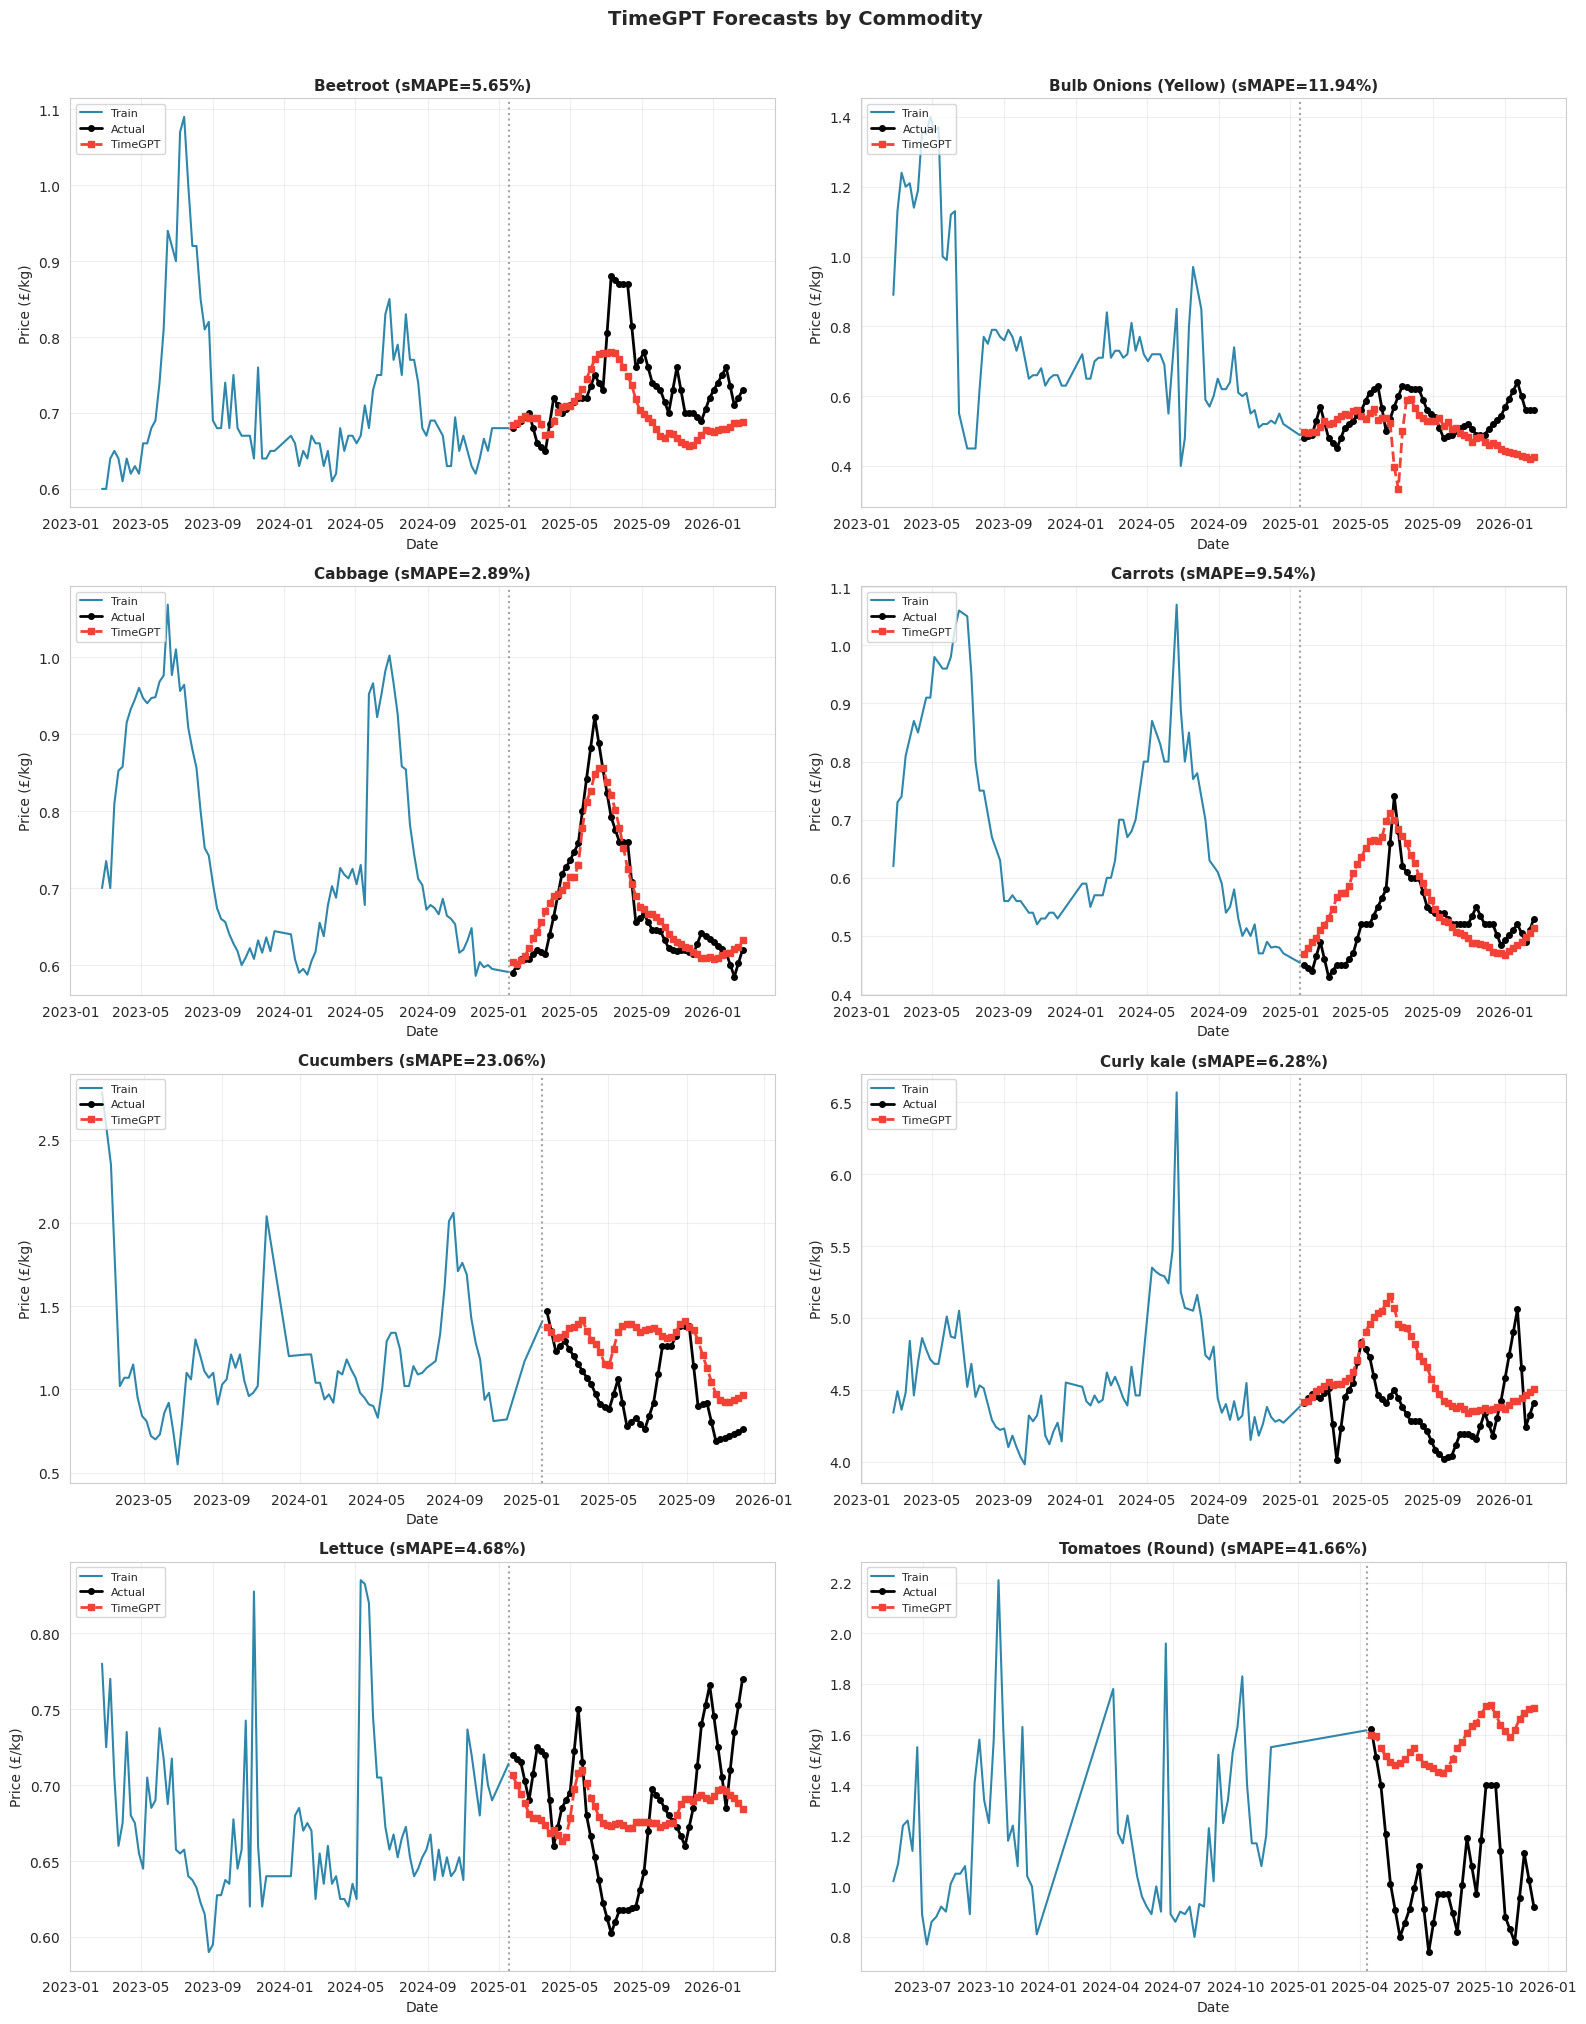

In [19]:
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for idx, comm in enumerate(commodities):
    ax = axes[idx]

    train_sub = nf_train[nf_train["unique_id"] == comm]
    test_sub = eval_df[eval_df["unique_id"] == comm]

    tail_n = min(100, len(train_sub))
    train_tail = train_sub.tail(tail_n)

    ax.plot(train_tail["ds"], train_tail["y"], label="Train", color="#2E86AB", linewidth=1.5)
    ax.plot(test_sub["ds"], test_sub["y"], label="Actual", color="black", linewidth=2, marker="o", markersize=4)
    ax.plot(test_sub["ds"], test_sub["TimeGPT"], label="TimeGPT", color="#F24236", linewidth=2, linestyle="--", marker="s", markersize=4)

    ax.axvline(x=train_sub["ds"].max(), color="gray", linestyle=":", linewidth=1.5, alpha=0.7)

    comm_metrics = per_commodity_df[per_commodity_df["Commodity"] == comm]
    if len(comm_metrics) > 0:
        smape_val = comm_metrics["sMAPE"].values[0]
        ax.set_title(f"{comm} (sMAPE={smape_val:.2%})", fontweight="bold", fontsize=11)
    else:
        ax.set_title(comm, fontweight="bold", fontsize=11)

    ax.legend(fontsize=8, loc="upper left")
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("Date")
    ax.set_ylabel("Price (£/kg)")

plt.suptitle("TimeGPT Forecasts by Commodity", fontweight="bold", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4 Summary

In [20]:
print("\n=== TimeGPT Summary ===\n")
print(metrics_df.to_string(index=False))
print(f"\nForecast horizon: {max_h} weeks")
print(f"Exogenous features used: {exog_cols}")



=== TimeGPT Summary ===

Metric    Value
   MSE 0.054817
  RMSE 0.234130
   MAE 0.136303
  MAPE 0.130860
 sMAPE 0.114491

Forecast horizon: 57 weeks
Exogenous features used: ['api_energy_and_lubricants', 'api_fertilisers_and_soil_improvers', 'api_plant_protection_products', 'api_fresh_fruit', 'api_fresh_vegetables', 'fuel_petrol_price', 'fuel_diesel_price', 'sppi_road_freight']
